# Aula 14 - Aprendizado Não Supervisionado - Parte 3 (Redução de Dimensionalidade & PCA)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 13, vimos como agrupar dados complexos usando DBSCAN e Dendrogramas. Mas quando o número de atributos de uma base cresce exponencialmente, a distância entre todos os pontos se torna quase igual (o Mal da Dimensionalidade) e não conseguimos plotar gráficos explicativos.
> 🎯 **Objetivo Principal da Aula:** Dominar a técnica de **Redução de Dimensionalidade** com **PCA (Principal Component Analysis)**, compreendendo a rotação ortogonal por autovetores, avaliando a **Razão de Variância Explicada Acumulada** e projetando dados multidimensionais em gráficos 2D de fácil interpretação.
> 🚀 **Para onde vamos:** Na próxima aula ('Fundamentos de Redes Neurais - Parte 1'), iniciaremos o módulo mais esperado da disciplina: **Deep Learning**. Deixaremos os algoritmos clássicos para trás e entenderemos como a matemática biológica inspirou a criação do **Neurônio Artificial e do Perceptron**.

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & A Maldição da Dimensionalidade** | O problema de visualizar tabelas com 10, 50 ou 100 colunas e a intuição da projeção ortogonal. |
| **Módulo 2** | **Mecanismo do PCA & Razão de Variância Explicada** | Como os componentes principais ortogonais capturam a máxima variância e o gráfico de Scree Plot. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 7 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Projeção 2D de diagnósticos médicos e teste de variância explicada. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & Redução de Dimensionalidade

### 1.1 O "Mal da Dimensionalidade"
À medida que adicionamos dezenas de colunas a uma tabela, o espaço amostral cresce exponencialmente, dificultando a visualização e tornando algoritmos propensos a *Overfitting*.

O **PCA (Principal Component Analysis)** encontra novos eixos ortogonais (**Componentes Principais**) apontando nas direções onde os dados possuem a maior variabilidade, permitindo projetar dados de 30 dimensões para 2 dimensões preservando quase toda a informação!

```mermaid
graph TD
    A["🌌 DADOS MULTIDIMENSIONAIS (30D / 50D)<br/>Impossível visualizar a olho humano"] --> B["📐 PCA (Projeção Ortogonal de Variância Múltipla)"]
    B --> C["🖼️ PROJEÇÃO PANORÂMICA 2D / 3D<br/>Preserva 85% a 95% da informação original!"]
```

> [!TIP]
> 🌌 **Analogia Geek — O Multiverso Marvel Reduzido para 2D:**
> Imagine tentar visualizar o mapa do Multiverso Marvel com 30 dimensões paralelas ao mesmo tempo. Nossos olhos humanos só conseguem enxergar em 2D ou 3D. O **PCA** tira uma "foto panorâmica perfeita" do Multiverso no ângulo em que as estrelas estão mais separadas umas das outras, permitindo que a gente enxergue todo o mapa 30D em uma tela 2D sem perder quase nada de detalhe!

> [!NOTE]
> 💡 **Curiosidade da Aula — Karl Pearson Inventando o PCA em 1901:**
> O PCA foi inventado em **1901 pelo matemático inglês Karl Pearson** (o mesmo criador da Correlação de Pearson!). Pearson desenvolveu o método como uma analogia mecânica ao *Teorema dos Eixos Principais* da mecânica de corpos rígidos. Foi Harold Hotelling em 1933 que expandiu a técnica para matrizes aleatórias na estatística moderna!  
> 🔗 **Documentação Scikit-Learn:** [scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O PCA reduz dezenas de colunas em poucas variáveis sintéticas (Componentes Principais) mantendo a máxima quantidade possível de informação original.

---

## Módulo 2: O Mecanismo por Dentro & Regras Práticas

### 2.1 Razão de Variância Explicada (`explained_variance_ratio_`)
Mede exatamente quanta informação original (%) foi preservada em cada componente principal.

> [!IMPORTANT]
> 💡 **Regra de Ouro:** O PCA exige estritamente que os dados numéricos estejam padronizados via `StandardScaler` (Média 0, Desvio 1) antes do cálculo dos componentes!

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** o PCA não cria dados novos; ele resume muitos atributos em menos dimensões, tentando preservar o que é mais informativo. Acompanhe a passagem de dados com muitas colunas para o gráfico 2D e use a variância explicada como resposta para “quanto da informação foi preservada?”.

---

### Bloco 3.1 — Importação de Módulos e Carregando o Wine Dataset

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que usar o dataset de vinhos (13 colunas) para testar o PCA?**  
> Porque é um caso clássico onde temos 13 variáveis químicas contínuas. Reduzir de 13D para 2D nos permite desenhar um gráfico e ver claramente o agrupamento dos vinhos.

In [1]:
# 1. Importamos as bibliotecas de processamento, gráficos e decomposição PCA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

# 2. Carregamos o dataset de vinhos (13 atributos químicos)
dados_brutos_vinho = load_wine()
matriz_entradas_vinho = dados_brutos_vinho.data
vetor_respostas_vinho = dados_brutos_vinho.target

# 3. Exibimos as dimensões do dataset original
print("--- DATASET DE VINHOS CARREGADO ---")
print(f"📐 Dimensão Original do Dataset: {matriz_entradas_vinho.shape} (178 amostras, 13 atributos)")

--- DATASET DE VINHOS CARREGADO ---
📐 Dimensão Original do Dataset: (178, 13) (178 amostras, 13 atributos)


---

### Bloco 3.2 — Padronização Obrigatória dos Dados (`StandardScaler`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que o `StandardScaler` é OBRIGATÓRIO antes do PCA?**  
> O PCA busca a máxima variância dos dados. Se o teor alcoólico varia de 11 a 14 e o magnésio varia de 70 a 160, o PCA achará que o magnésio tem "mais informação" só porque seus números são maiores. A padronização corrige esse desequilíbrio!

In [2]:
# 1. Instanciamos o objeto padronizador de escala
escalonador_padronizado = StandardScaler()

# 2. Aplicamos a padronização aos dados numéricos dos vinhos
matriz_dados_padronizados = escalonador_padronizado.fit_transform(matriz_entradas_vinho)

# 3. Exibimos a confirmação de execução
print("--- PADRONIZAÇÃO DE ESCALA PREVIA ---")
print("✅ Dados químicos padronizados com Média = 0 e Desvio Padrão = 1.")

--- PADRONIZAÇÃO DE ESCALA PREVIA ---
✅ Dados químicos padronizados com Média = 0 e Desvio Padrão = 1.


---

### Bloco 3.3 — Instanciando e Treinando o PCA para 2 Componentes (`n_components=2`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que o parâmetro `n_components=2` faz?**  
> Ele instrui o PCA a comprimir e projetar as 13 colunas originais em apenas **2 novos eixos sintéticos principais (PC1 e PC2)**.

In [3]:
# 1. Instanciamos o PCA para extrair 2 componentes (PC1 e PC2)
modelo_pca_2d = PCA(n_components=2, random_state=42)

# 2. O MOMENTO DA COMPRESSÃO/PROJEÇÃO: O PCA reduz a matriz 13D para 2D
matriz_dados_pca_2d = modelo_pca_2d.fit_transform(matriz_dados_padronizados)

# 3. Exibimos as novas dimensões da matriz projetada
print("--- REDUÇÃO DE DIMENSIONALIDADE (13D ──► 2D) ---")
print(f"📐 Dimensão dos Dados APÓS o PCA: {matriz_dados_pca_2d.shape} (178 amostras, 2 componentes)")

--- REDUÇÃO DE DIMENSIONALIDADE (13D ──► 2D) ---
📐 Dimensão dos Dados APÓS o PCA: (178, 2) (178 amostras, 2 componentes)


---

### Bloco 3.4 — Extraindo a Razão de Variância Explicada (`explained_variance_ratio_`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que significa a porcentagem de variância explicada?**  
> Indica o percentual exato da informação original que foi "salva" e mantida dentro das duas componentes principais (PC1 e PC2).

In [4]:
# 1. Extraímos o vetor com a porcentagem de variância mantida em cada componente
variabilidade_componentes = modelo_pca_2d.explained_variance_ratio_

# 2. Exibimos os relatórios de variância no console
print("--- RAZÃO DE VARIÂNCIA EXPLICADA ---")
print(f"📊 Variância explicada pelo PC1: {variabilidade_componentes[0] * 100:.2f}%")
print(f"📊 Variância explicada pelo PC2: {variabilidade_componentes[1] * 100:.2f}%")
print(f"🌟 Variância Acumulada Preservada (PC1 + PC2): {np.sum(variabilidade_componentes) * 100:.2f}% da informação original!")

--- RAZÃO DE VARIÂNCIA EXPLICADA ---
📊 Variância explicada pelo PC1: 36.20%
📊 Variância explicada pelo PC2: 19.21%
🌟 Variância Acumulada Preservada (PC1 + PC2): 55.41% da informação original!


---

### Bloco 3.5 — Visualizando o Dataset 13D Projetado em 2D

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como interpretamos o gráfico 2D do PCA?**  
> O eixo X é a primeira componente (`PC1`) e o eixo Y é a segunda (`PC2`). Repare como as 3 classes de vinhos aparecem perfeitamente separadas em um plano bidimensional limpo!

🎨 Exibindo a projeção 2D do PCA no Colab...


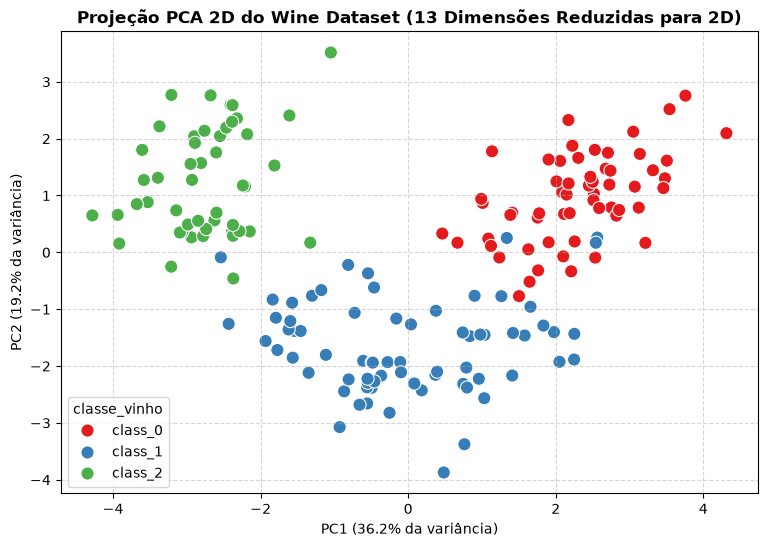

In [5]:
# 1. Estruturamos os dados projetados em um DataFrame com colunas PC1 e PC2
tabela_pca_2d = pd.DataFrame(matriz_dados_pca_2d, columns=['PC1', 'PC2'])
tabela_pca_2d['classe_vinho'] = pd.Categorical.from_codes(vetor_respostas_vinho, dados_brutos_vinho.target_names)

# 2. Definimos as dimensões da figura do gráfico
plt.figure(figsize=(9, 6))

# 3. Desenhamos a dispersão colorindo os pontos por classe de vinho
sns.scatterplot(data=tabela_pca_2d, x='PC1', y='PC2', hue='classe_vinho', palette='Set1', s=90)

# 4. Adicionamos rótulos informando o percentual de variância nos eixos
plt.title("Projeção PCA 2D do Wine Dataset (13 Dimensões Reduzidas para 2D)", fontweight='bold')
plt.xlabel(f"PC1 ({variabilidade_componentes[0] * 100:.1f}% da variância)")
plt.ylabel(f"PC2 ({variabilidade_componentes[1] * 100:.1f}% da variância)")
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Renderizamos o gráfico no notebook
print("🎨 Exibindo a projeção 2D do PCA no Colab...")
plt.show()

---

### Bloco 3.6 — Plotando o Gráfico de Cotovelo da Variância Acumulada (*Scree Plot*)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que é um Scree Plot?**  
> É o gráfico que mostra quanta informação acumulada (%) mantemos ao adicionar $1, 2, 3, \dots, N$ componentes. Usamos a linha guia de 85% para saber exatamente quantas componentes precisamos manter.

🎨 Exibindo o Scree Plot de variância acumulada...


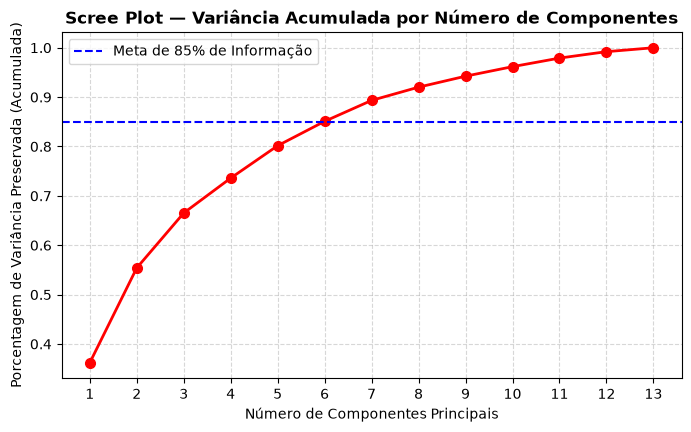

In [6]:
# 1. Instanciamos e ajustamos um PCA mantendo todas as 13 componentes
modelo_pca_completo = PCA().fit(matriz_dados_padronizados)

# 2. Calculamos a soma acumulada das variâncias com np.cumsum
variancia_explicada_acumulada = np.cumsum(modelo_pca_completo.explained_variance_ratio_)

# 3. Plotamos o gráfico do Scree Plot
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, 14), variancia_explicada_acumulada, 'ro-', linewidth=2, markersize=7)
plt.axhline(y=0.85, color='blue', linestyle='--', label='Meta de 85% de Informação')

# 4. Adicionamos rótulos explicativos aos eixos
plt.title("Scree Plot — Variância Acumulada por Número de Componentes", fontweight='bold')
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Porcentagem de Variância Preservada (Acumulada)")
plt.xticks(range(1, 14))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 5. Exibimos o gráfico no notebook
print("🎨 Exibindo o Scree Plot de variância acumulada...")
plt.show()

---

### Bloco 3.7 — Reduzindo Imagens de Dígitos Manuscritos com PCA (64D ──► 2D)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como o PCA reduz imagens de 64 pixels em 2D?**  
> Cada imagem do dataset tem 64 pixels (uma matriz $8 \times 8$). O PCA pega esses 64 valores por imagem e projeta em 2 números ($X$ e $Y$), mantendo os números de 0 a 9 em aglomerados bem definidos por cor!

🎨 Exibindo o mapa visual de imagens de dígitos manuscritos reduzidos para 2D...


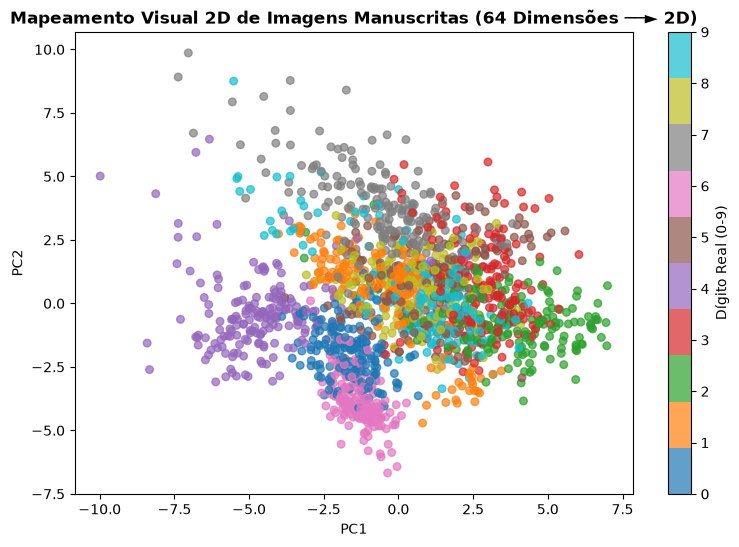

In [7]:
# 1. Importamos o dataset de dígitos manuscritos
from sklearn.datasets import load_digits

# 2. Carregamos o dataset de imagens de dígitos
dados_digitos = load_digits()
matriz_digitos_64d = dados_digitos.data # 1797 imagens de 64 pixels
vetor_respostas_digitos = dados_digitos.target

# 3. Aplicamos padronização e reduzimos de 64D para 2D com o PCA
pca_digitos = PCA(n_components=2, random_state=42)
matriz_digitos_2d = pca_digitos.fit_transform(StandardScaler().fit_transform(matriz_digitos_64d))

# 4. Plotamos a dispersão visual colorindo por número real (0 a 9)
plt.figure(figsize=(9, 6))
grafico_dispersao = plt.scatter(matriz_digitos_2d[:, 0], matriz_digitos_2d[:, 1], c=vetor_respostas_digitos, cmap='tab10', alpha=0.7, s=30)
plt.colorbar(grafico_dispersao, label='Dígito Real (0-9)')
plt.title("Mapeamento Visual 2D de Imagens Manuscritas (64 Dimensões ──► 2D)", fontweight='bold')
plt.xlabel("PC1")
plt.ylabel("PC2")

# 5. Renderizamos a imagem final
print("🎨 Exibindo o mapa visual de imagens de dígitos manuscritos reduzidos para 2D...")
plt.show()

---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere o código do Breast Cancer Dataset abaixo para testar a redução de 30 dimensões:

1. **Altere o número de componentes:** Na linha `quantidade_componentes_estudante = 2`, experimente alterar para `3` ou `4`.
2. **Re-execute e observe:** Veja como a soma da variância acumulada preservada aumenta a cada nova componente adicionada!

In [8]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Carregamos o dataset médico com 30 colunas e aplicamos o StandardScaler
dados_cancer = load_breast_cancer()
matriz_cancer_padronizada = StandardScaler().fit_transform(dados_cancer.data)

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE A QUANTIDADE DE COMPONENTES:
# -----------------------------------------------------------------------------
quantidade_componentes_estudante = 2 # Tente mudar para 3 ou 4 componentes!

# 2. Instanciamos e executamos o PCA personalizado do estudante
pca_estudante = PCA(n_components=quantidade_componentes_estudante, random_state=42)
matriz_cancer_reduzida = pca_estudante.fit_transform(matriz_cancer_padronizada)

# 3. Calculamos a variância explicada acumulada
variancia_acumulada_estudante = np.sum(pca_estudante.explained_variance_ratio_)

# 4. Exibimos o relatório da sua experimentação
print(f"--- RELATÓRIO DO SEU TESTE DE PCA ({quantidade_componentes_estudante} COMPONENTES) ---")
print(f"Dimensão Original dos Dados: {dados_cancer.data.shape[1]} colunas médicas")
print(f"Dimensão Nova Reduzida:      {matriz_cancer_reduzida.shape[1]} componentes")
print(f"📊 Porcentagem de Informação Preservada: {variancia_acumulada_estudante * 100:.2f}%")

--- RELATÓRIO DO SEU TESTE DE PCA (2 COMPONENTES) ---
Dimensão Original dos Dados: 30 colunas médicas
Dimensão Nova Reduzida:      2 componentes
📊 Porcentagem de Informação Preservada: 63.24%


---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — Como o cérebro humano inspirou o Deep Learning?**  
> No nosso cérebro, um neurônio recebe sinais elétricos pelos dendritos; se a soma desses estímulos ultrapassar um limiar, o neurônio 'dispara' um sinal pelo axônio. Na **Aula 15**, construiremos a réplica matemática desse mecanismo: entradas ($x$), pesos ($w$), viés ($b$) e uma **Função de Ativação** (como ReLU ou Sigmoide) que decide se o neurônio deve disparar ou ficar em silêncio!
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Tente resolver mentalmente: se $x_1 = 2$, $w_1 = 3$, $x_2 = 1$, $w_2 = -1$ e $b = 1$, qual é a soma ponderada $z = (x_1 w_1 + x_2 w_2) + b$? (Resposta: $2 \times 3 + 1 \times (-1) + 1 = 6$). É essa multiplicação que faremos na lousa e no código!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi o que é o "Mal da Dimensionalidade" e por que precisamos reduzir atributos.
- [ ] Sei aplicar a padronização `StandardScaler` antes de instanciar o `PCA`.
- [ ] Entendi como interpretar a Razão de Variância Explicada (`explained_variance_ratio_`).
- [ ] Consigo alterar a quantidade de componentes principais e analisar a variância acumulada.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 8: PCA).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 14: Redução de Dimensionalidade com PCA

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *Optical Recognition of Handwritten Digits* (1.797 imagens de dígitos 8x8 = 64 dimensões)

---

## 🎯 Objetivo do Laboratório
Comprimir um espaço de 64 dimensões (pixels) em apenas 2 eixos principais utilizando **PCA (Principal Component Analysis)**: calcular a razão de variância explicada, plotar a dispersão 2D dos 10 dígitos e construir o gráfico de variância acumulada (*Scree Plot*).

---

### Passo 1 — Carregando o Dataset de Dígitos (64 Dimensões)

In [9]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# 1. Carregamos 1.797 imagens de dígitos manuscritos de 0 a 9
dados_digitos = load_digits()
X = dados_digitos.data  # 1.797 linhas x 64 pixels (dimensões)
y = dados_digitos.target

print(f"Dimensão da base original: {X.shape[0]} imagens x {X.shape[1]} dimensões (pixels)")

# 2. Padronizamos os dados
X_scaled = StandardScaler().fit_transform(X)

Dimensão da base original: 1797 imagens x 64 dimensões (pixels)


---

### Passo 2 — Redução para 2 Componentes Principais (`PCA(n_components=2)`)

In [10]:
from sklearn.decomposition import PCA

# 1. Instanciamos e treinamos o PCA para extrair 2 dimensões
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# 2. Extraímos o percentual de informação preservada
variancia = pca_2d.explained_variance_ratio_
print(f"Variância explicada pelo CP1: {variancia[0] * 100:.2f}%")
print(f"Variância explicada pelo CP2: {variancia[1] * 100:.2f}%")
print(f"Total de informação preservada em 2D: {variancia.sum() * 100:.2f}%")

Variância explicada pelo CP1: 12.03%
Variância explicada pelo CP2: 9.56%
Total de informação preservada em 2D: 21.59%


---

### Passo 3 — Visualizando o Dataset de 64D Projetado no Plano 2D

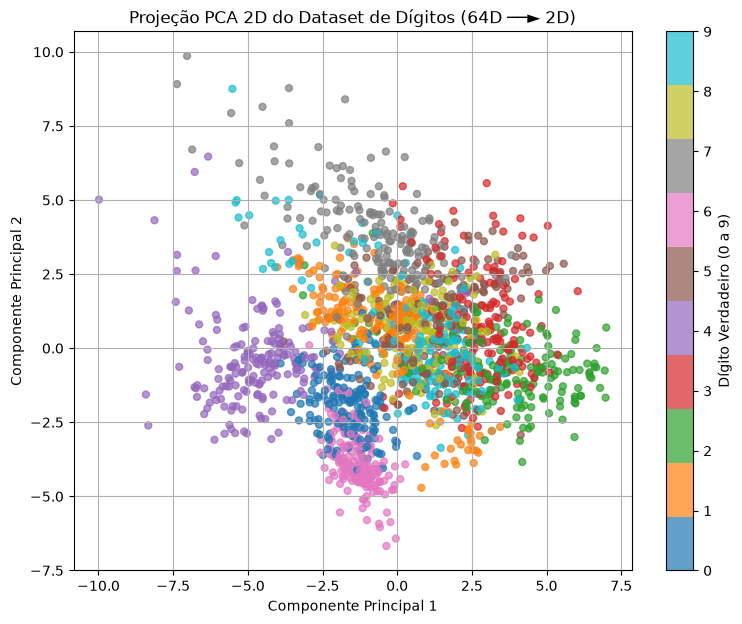

In [11]:
# 1. Plotamos a projeção 2D com cores para cada um dos 10 dígitos (0 a 9)
plt.figure(figsize=(9, 7))
scatter = plt.scatter(
    X_pca_2d[:, 0], 
    X_pca_2d[:, 1], 
    c=y, 
    cmap='tab10', 
    alpha=0.7, 
    s=25
)
plt.colorbar(scatter, label='Dígito Verdadeiro (0 a 9)')
plt.title("Projeção PCA 2D do Dataset de Dígitos (64D ──► 2D)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)
plt.show()

---

### Passo 4 — Gráfico da Variância Explicada Acumulada (*Scree Plot*)

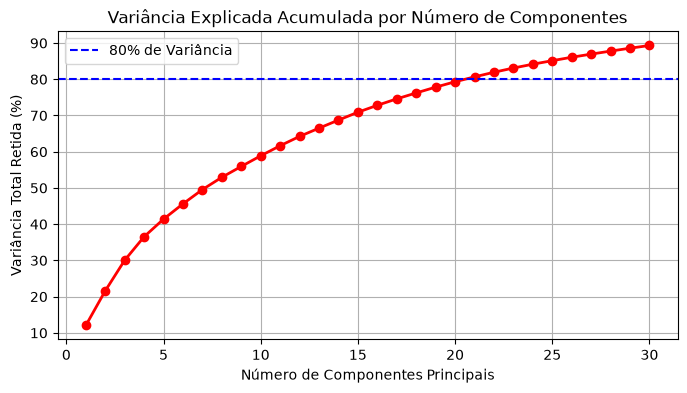

In [12]:
# 1. Treinamos o PCA com 30 componentes para ver a curva de saturação
pca_30 = PCA(n_components=30)
pca_30.fit(X_scaled)
variancia_acumulada = np.cumsum(pca_30.explained_variance_ratio_) * 100

# 2. Plotamos a curva
plt.figure(figsize=(8, 4))
plt.plot(range(1, 31), variancia_acumulada, 'ro-', linewidth=2)
plt.axhline(y=80, color='b', linestyle='--', label='80% de Variância')
plt.title("Variância Explicada Acumulada por Número de Componentes")
plt.xlabel("Número de Componentes Principais")
plt.ylabel("Variância Total Retida (%)")
plt.legend()
plt.grid(True)
plt.show()

---

## 🏆 Desafio Técnico de Validação
Descubra no gráfico quantas componentes principais são necessárias para reter pelo menos **$80\%$** de toda a informação original dos dígitos.

In [13]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
